# Visualización de personas diagnosticadas con diabetes en Puebla

## Análisis supervisado conectado al dataset de 15,000 pacientes

Este notebook desarrolla, paso a paso, un flujo completo de **aprendizaje supervisado** para estimar la probabilidad de diagnóstico de diabetes y visualizar su distribución geográfica en el estado de Puebla.

### Objetivos

1. Cargar el archivo `dataset_pacientes_puebla_15000_unificado.csv`.
2. Revisar y preparar los 15,000 registros.
3. Construir una variable objetivo para el entrenamiento.
4. Separar datos de entrenamiento y prueba.
5. Entrenar y comparar varios modelos.
6. Mostrar métricas, matriz de confusión, curva ROC y validación cruzada.
7. Mostrar cómo evoluciona el modelo conforme recibe más datos de entrenamiento.
8. Identificar las variables más importantes.
9. Visualizar pacientes diagnosticados y probabilidades estimadas en mapas de Puebla.

> **Aviso académico:** el dataset proporcionado no contiene glucosa, HbA1c ni una columna real de diagnóstico. Para demostrar un análisis supervisado, el notebook genera una etiqueta sintética y reproducible a partir de las variables disponibles. No representa un diagnóstico médico real.

## 1. Importación de librerías

La primera línea puede descomentarse solamente cuando falte alguna dependencia.

In [1]:
# Descomentar solamente si hace falta instalar dependencias:
# %pip install -q pandas numpy matplotlib folium scikit-learn

from pathlib import Path
from time import perf_counter
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import folium
from folium import plugins

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    RocCurveDisplay,
    roc_auc_score
)
from sklearn.model_selection import (
    StratifiedKFold,
    StratifiedShuffleSplit,
    cross_validate,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda valor: f"{valor:,.3f}")

RANDOM_STATE = 42

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Carga del dataset unificado

El código busca el CSV en diferentes rutas. Esto permite ejecutar el notebook cuando:

- el CSV está en la misma carpeta;
- el notebook está en `practica08` y el CSV está en `practica07`;
- el proyecto completo se ejecuta desde la carpeta principal.

In [2]:
nombre_archivo = "dataset_pacientes_puebla_15000_unificado.csv"

rutas_candidatas = [
    Path(nombre_archivo),
    Path("../practica07") / nombre_archivo,
    Path("./practica07") / nombre_archivo,
    Path("/mnt/data") / nombre_archivo
]

ruta_dataset = next(
    (ruta for ruta in rutas_candidatas if ruta.exists()),
    None
)

if ruta_dataset is None:
    rutas_revisadas = "\n".join(
        f"- {ruta.resolve()}" for ruta in rutas_candidatas
    )
    raise FileNotFoundError(
        f"No se encontró el archivo {nombre_archivo}.\n"
        f"Rutas revisadas:\n{rutas_revisadas}"
    )

pacientes_df = pd.read_csv(ruta_dataset)

pacientes_df["fecha_registro"] = pd.to_datetime(
    pacientes_df["fecha_registro"],
    dayfirst=True,
    errors="coerce"
)

print("Dataset cargado desde:", ruta_dataset.resolve())
print("Número de registros:", f"{len(pacientes_df):,}")
print("Número de columnas:", pacientes_df.shape[1])

display(pacientes_df.head())

Dataset cargado desde: C:\Users\tass1\Downloads\ECBD_9B_IDGS__Practicas_230369\practica07\dataset_pacientes_puebla_15000_unificado.csv
Número de registros: 15,000
Número de columnas: 16


,paciente_id,fecha_registro,municipio,region,tipo_area,latitud,longitud,edad,grupo_edad,sexo,talla_cm,peso_kg,imc,presion_sistolica,presion_diastolica,colesterol_ldl
0,PUE-CV-00001,2023-08-17,Zacapoaxtla,Valle de Atlixco,Urbana,18.491,-97.548,87,75+,M,170.800,44.200,15.200,121,73,149
1,PUE-CV-00002,2025-10-31,Tlahuapan,Sierra Norte,Periurbana,18.437,-97.695,87,75+,F,153.400,82.100,34.900,110,70,198
2,PUE-CV-00003,2024-11-27,Xicotepec,Angelópolis,Urbana,20.106,-98.228,29,18-44,F,147.500,99.600,45.800,143,62,207
3,PUE-CV-00004,2026-01-03,Puebla,Valle de Tehuacán,Urbana,19.214,-97.390,64,60-74,M,176.100,45.100,14.500,139,78,110
4,PUE-CV-00005,2024-04-21,Puebla,Valle de Tehuacán,Rural,18.998,-97.382,38,18-44,F,159.700,87.600,34.300,119,98,133


## 3. Comprobación de las columnas requeridas

Antes de continuar, se verifica que el archivo contenga las variables necesarias.

In [3]:
columnas_requeridas = [
    "paciente_id",
    "municipio",
    "region",
    "tipo_area",
    "latitud",
    "longitud",
    "edad",
    "sexo",
    "imc",
    "presion_sistolica",
    "presion_diastolica",
    "colesterol_ldl"
]

columnas_faltantes = [
    columna
    for columna in columnas_requeridas
    if columna not in pacientes_df.columns
]

if columnas_faltantes:
    raise ValueError(
        "El dataset no contiene las siguientes columnas requeridas: "
        + ", ".join(columnas_faltantes)
    )

print("Todas las columnas requeridas están disponibles.")

Todas las columnas requeridas están disponibles.


## 4. Auditoría de calidad de los datos

Se revisan dimensiones, tipos de datos, valores nulos, registros duplicados e identificadores repetidos.

In [4]:
resumen_calidad = pd.DataFrame({
    "tipo_dato": pacientes_df.dtypes.astype(str),
    "valores_nulos": pacientes_df.isna().sum(),
    "porcentaje_nulos": (
        pacientes_df.isna().mean() * 100
    ).round(2),
    "valores_unicos": pacientes_df.nunique()
}).sort_values(
    ["valores_nulos", "valores_unicos"],
    ascending=[False, False]
)

print(
    "Registros completamente duplicados:",
    pacientes_df.duplicated().sum()
)

print(
    "Identificadores de paciente duplicados:",
    pacientes_df["paciente_id"].duplicated().sum()
)

display(resumen_calidad)

Registros completamente duplicados: 0
Identificadores de paciente duplicados: 0


,tipo_dato,valores_nulos,porcentaje_nulos,valores_unicos
paciente_id,object,0,0.000,15000
latitud,float64,0,0.000,14958
longitud,float64,0,0.000,14949
fecha_registro,datetime64[ns],0,0.000,1639
peso_kg,float64,0,0.000,801
talla_cm,float64,0,0.000,491
imc,float64,0,0.000,452
colesterol_ldl,int64,0,0.000,171
presion_sistolica,int64,0,0.000,81
edad,int64,0,0.000,73


In [5]:
variables_numericas = [
    "edad",
    "talla_cm",
    "peso_kg",
    "imc",
    "presion_sistolica",
    "presion_diastolica",
    "colesterol_ldl",
    "latitud",
    "longitud"
]

display(
    pacientes_df[variables_numericas]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
edad,"15,000.000",54.173,21.044,18.000,36.000,54.000,72.000,90.000
talla_cm,"15,000.000",167.729,13.649,143.000,155.875,167.800,179.500,192.000
peso_kg,"15,000.000",78.614,21.982,40.000,59.700,78.600,97.000,120.000
imc,"15,000.000",28.498,9.291,11.100,21.100,27.700,34.700,56.900
presion_sistolica,"15,000.000",145.280,22.494,105.000,126.000,146.000,165.000,185.000
presion_diastolica,"15,000.000",81.568,12.868,60.000,70.000,81.000,93.000,105.000
colesterol_ldl,"15,000.000",165.034,47.764,80.000,124.000,165.000,206.000,250.000
latitud,"15,000.000",19.300,0.771,18.000,18.637,19.285,19.939,20.800
longitud,"15,000.000",-97.990,0.597,-99.100,-98.499,-97.988,-97.479,-96.900


## 5. Construcción de la variable objetivo

El aprendizaje supervisado requiere un resultado conocido. Como el CSV original no contiene una columna de diagnóstico, se crean dos variables académicas:

- `probabilidad_base_diabetes`: probabilidad sintética calculada con los factores disponibles.
- `diagnostico_diabetes`: etiqueta binaria utilizada para entrenar.
  - `1`: diagnóstico positivo simulado.
  - `0`: diagnóstico negativo simulado.

La etiqueta se genera con una semilla fija para que siempre produzca los mismos resultados.

In [6]:
def sigmoide(valor):
    return 1 / (1 + np.exp(-valor))


generador = np.random.default_rng(RANDOM_STATE)

puntaje_latente = (
    -4.0
    + 0.035 * (pacientes_df["edad"] - 40)
    + 0.120 * (pacientes_df["imc"] - 25)
    + 0.018 * (
        pacientes_df["presion_sistolica"] - 120
    )
    + 0.012 * (
        pacientes_df["presion_diastolica"] - 80
    )
    + 0.008 * (
        pacientes_df["colesterol_ldl"] - 130
    )
    + 0.250 * pacientes_df[
        "tipo_area"
    ].eq("Urbana").astype(int)
    + 0.150 * pacientes_df[
        "sexo"
    ].eq("M").astype(int)
)

pacientes_df["probabilidad_base_diabetes"] = sigmoide(
    puntaje_latente
)

pacientes_df["diagnostico_diabetes"] = generador.binomial(
    n=1,
    p=pacientes_df["probabilidad_base_diabetes"]
)

pacientes_df["diagnostico_texto"] = pacientes_df[
    "diagnostico_diabetes"
].map({
    0: "No diagnosticado",
    1: "Diagnosticado"
})

columnas_muestra = [
    "paciente_id",
    "edad",
    "imc",
    "presion_sistolica",
    "presion_diastolica",
    "colesterol_ldl",
    "probabilidad_base_diabetes",
    "diagnostico_texto"
]

display(
    pacientes_df[columnas_muestra].head(10)
)

,paciente_id,edad,imc,presion_sistolica,presion_diastolica,colesterol_ldl,probabilidad_base_diabetes,diagnostico_texto
0,PUE-CV-00001,87,15.200,121,73,149,0.045,No diagnosticado
1,PUE-CV-00002,87,34.900,110,70,198,0.284,No diagnosticado
2,PUE-CV-00003,29,45.800,143,62,207,0.305,Diagnosticado
3,PUE-CV-00004,64,14.500,139,78,110,0.021,No diagnosticado
4,PUE-CV-00005,38,34.300,119,98,133,0.061,No diagnosticado
5,PUE-CV-00006,89,32.400,117,74,98,0.164,Diagnosticado
6,PUE-CV-00007,58,22.800,168,69,157,0.092,No diagnosticado
7,PUE-CV-00008,69,46.700,175,91,113,0.647,No diagnosticado
8,PUE-CV-00009,26,42.400,177,76,231,0.351,No diagnosticado
9,PUE-CV-00010,55,18.700,143,92,135,0.026,No diagnosticado


## 6. Distribución de la variable objetivo

Esta revisión permite identificar cuántos pacientes pertenecen a cada clase y comprobar si existe desbalance.

In [7]:
distribucion_objetivo = (
    pacientes_df["diagnostico_texto"]
    .value_counts()
    .rename_axis("clase")
    .reset_index(name="pacientes")
)

distribucion_objetivo["porcentaje"] = (
    distribucion_objetivo["pacientes"]
    / len(pacientes_df)
    * 100
).round(2)

display(distribucion_objetivo)

,clase,pacientes,porcentaje
0,No diagnosticado,12468,83.120
1,Diagnosticado,2532,16.880


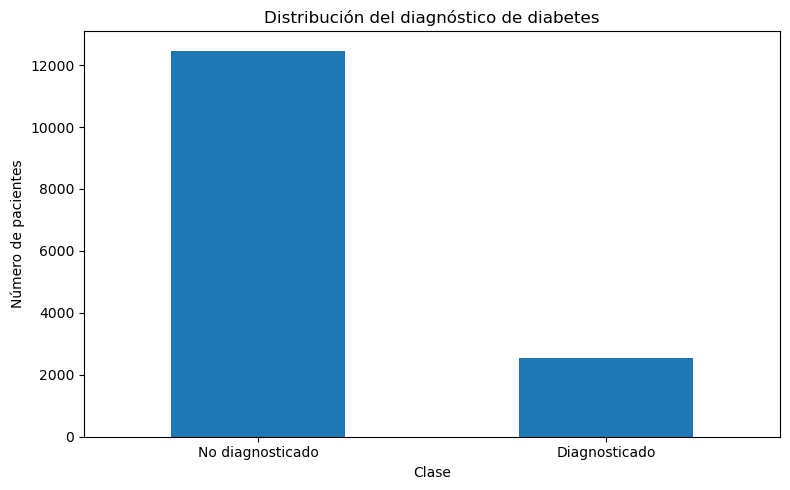

In [8]:
conteo_objetivo = pacientes_df[
    "diagnostico_texto"
].value_counts()

plt.figure(figsize=(8, 5))
conteo_objetivo.plot(kind="bar")
plt.title("Distribución del diagnóstico de diabetes")
plt.xlabel("Clase")
plt.ylabel("Número de pacientes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Exploración de los factores asociados

Se comparan las variables clínicas disponibles entre pacientes diagnosticados y no diagnosticados.

In [9]:
comparacion_clinica = (
    pacientes_df
    .groupby("diagnostico_texto")[
        [
            "edad",
            "imc",
            "presion_sistolica",
            "presion_diastolica",
            "colesterol_ldl"
        ]
    ]
    .agg(["mean", "median", "std"])
    .round(2)
)

display(comparacion_clinica)

edad                  imc              presion_sistolica  \
                    mean median    std   mean median   std              mean   
diagnostico_texto                                                              
Diagnosticado     63.670 67.000 19.520 36.090 36.100 9.110           151.470   
No diagnosticado  52.250 51.000 20.820 26.960 26.200 8.540           144.020   

                                 presion_diastolica                \
                   median    std               mean median    std   
diagnostico_texto                                                   
Diagnosticado     154.000 21.640             82.830 84.000 12.790   
No diagnosticado  144.000 22.460             81.310 81.000 12.870   

                  colesterol_ldl                 
                            mean  median    std  
diagnostico_texto                                
Diagnosticado            176.480 181.000 47.530  
No diagnosticado         162.710 162.000 47.480

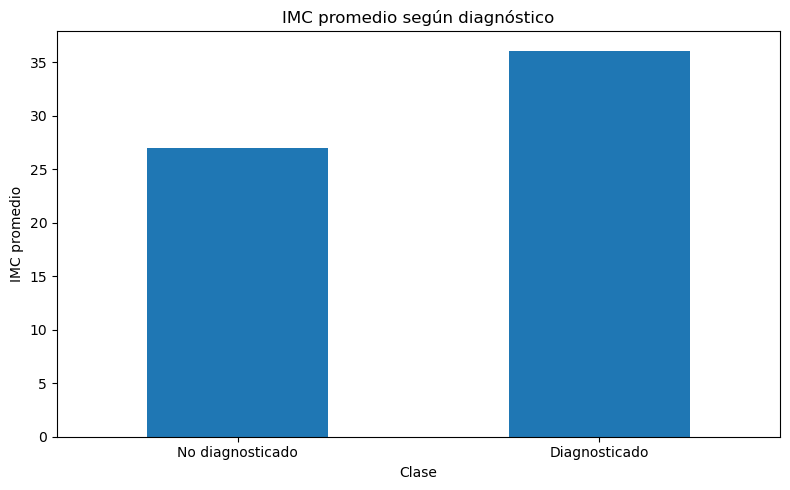

In [10]:
promedios_imc = (
    pacientes_df
    .groupby("diagnostico_texto")["imc"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 5))
promedios_imc.plot(kind="bar")
plt.title("IMC promedio según diagnóstico")
plt.xlabel("Clase")
plt.ylabel("IMC promedio")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

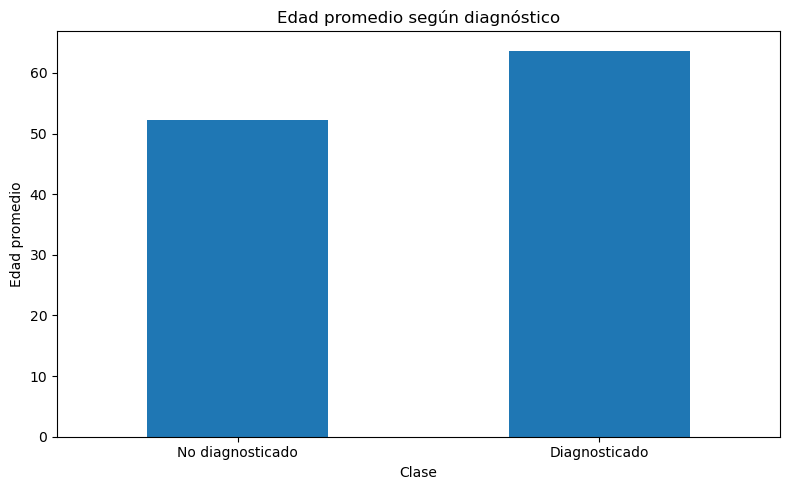

In [11]:
promedios_edad = (
    pacientes_df
    .groupby("diagnostico_texto")["edad"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 5))
promedios_edad.plot(kind="bar")
plt.title("Edad promedio según diagnóstico")
plt.xlabel("Clase")
plt.ylabel("Edad promedio")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Definición de variables predictoras

Se excluyen variables que podrían provocar fuga de información o duplicar características:

- `paciente_id`: identificador.
- `fecha_registro`: no es una medición clínica.
- `grupo_edad`: repite información contenida en `edad`.
- `talla_cm` y `peso_kg`: están resumidos en el IMC.
- `municipio`, `latitud` y `longitud`: se reservan para la visualización.
- `probabilidad_base_diabetes`: se utilizó para generar la etiqueta.

In [12]:
variables_numericas_modelo = [
    "edad",
    "imc",
    "presion_sistolica",
    "presion_diastolica",
    "colesterol_ldl"
]

variables_categoricas_modelo = [
    "sexo",
    "region",
    "tipo_area"
]

variables_modelo = (
    variables_numericas_modelo
    + variables_categoricas_modelo
)

objetivo = "diagnostico_diabetes"

X = pacientes_df[variables_modelo].copy()
y = pacientes_df[objetivo].copy()

print("Variables del modelo:")
for variable in variables_modelo:
    print("-", variable)

print("\nDimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Variables del modelo:
- edad
- imc
- presion_sistolica
- presion_diastolica
- colesterol_ldl
- sexo
- region
- tipo_area

Dimensiones de X: (15000, 8)
Dimensiones de y: (15000,)


## 9. Separación de entrenamiento y prueba

Se utiliza:

- 80 % de los registros para entrenamiento.
- 20 % de los registros para prueba.
- Estratificación para conservar la proporción de diagnósticos.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

resumen_particion = pd.DataFrame({
    "conjunto": [
        "Entrenamiento",
        "Prueba"
    ],
    "registros": [
        len(X_train),
        len(X_test)
    ],
    "diagnosticados": [
        int(y_train.sum()),
        int(y_test.sum())
    ],
    "porcentaje_diagnosticados": [
        round(y_train.mean() * 100, 2),
        round(y_test.mean() * 100, 2)
    ]
})

display(resumen_particion)

,conjunto,registros,diagnosticados,porcentaje_diagnosticados
0,Entrenamiento,12000,2026,16.880
1,Prueba,3000,506,16.870


## 10. Preprocesamiento

El preprocesamiento se integra dentro de una tubería:

### Variables numéricas

- Imputación por mediana.
- Estandarización.

### Variables categóricas

- Imputación por moda.
- Codificación *one-hot*.

Al usar una tubería, el preprocesamiento se aprende únicamente con el conjunto de entrenamiento.

In [14]:
transformador_numerico = Pipeline(steps=[
    (
        "imputacion",
        SimpleImputer(strategy="median")
    ),
    (
        "escalado",
        StandardScaler()
    )
])

transformador_categorico = Pipeline(steps=[
    (
        "imputacion",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "one_hot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocesador = ColumnTransformer(
    transformers=[
        (
            "numericas",
            transformador_numerico,
            variables_numericas_modelo
        ),
        (
            "categoricas",
            transformador_categorico,
            variables_categoricas_modelo
        )
    ]
)

print(preprocesador)

ColumnTransformer(transformers=[('numericas',
                                 Pipeline(steps=[('imputacion',
                                                  SimpleImputer(strategy='median')),
                                                 ('escalado',
                                                  StandardScaler())]),
                                 ['edad', 'imc', 'presion_sistolica',
                                  'presion_diastolica', 'colesterol_ldl']),
                                ('categoricas',
                                 Pipeline(steps=[('imputacion',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('one_hot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sexo', 'region', 'tipo_area'])])


## 11. Modelos que se entrenarán

Se comparan tres alternativas:

1. **Modelo base:** siempre selecciona la clase mayoritaria.
2. **Regresión logística:** modelo lineal e interpretable.
3. **Bosque aleatorio:** modelo no lineal que puede representar interacciones.

Los modelos principales utilizan balanceo de clases.

In [15]:
modelos = {
    "Modelo base": Pipeline(steps=[
        (
            "preprocesador",
            preprocesador
        ),
        (
            "modelo",
            DummyClassifier(
                strategy="most_frequent"
            )
        )
    ]),
    "Regresión logística": Pipeline(steps=[
        (
            "preprocesador",
            preprocesador
        ),
        (
            "modelo",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]),
    "Bosque aleatorio": Pipeline(steps=[
        (
            "preprocesador",
            preprocesador
        ),
        (
            "modelo",
            RandomForestClassifier(
                n_estimators=150,
                max_depth=12,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=1
            )
        )
    ])
}

print("Modelos preparados:")
for nombre in modelos:
    print("-", nombre)

Modelos preparados:
- Modelo base
- Regresión logística
- Bosque aleatorio


## 12. Entrenamiento y comparación de modelos

En esta sección se observa el entrenamiento de cada algoritmo, el tiempo utilizado y su rendimiento en el conjunto de prueba.

### Métricas

- `accuracy`: proporción total de aciertos.
- `precision`: cuántos positivos predichos eran correctos.
- `recall`: cuántos diagnosticados fueron detectados.
- `f1`: equilibrio entre precisión y recall.
- `roc_auc`: capacidad general de separar ambas clases.

In [16]:
resultados = []
predicciones_modelos = {}
probabilidades_modelos = {}
modelos_entrenados = {}

for nombre, modelo in modelos.items():
    print(f"Entrenando: {nombre}...")

    inicio = perf_counter()
    modelo.fit(X_train, y_train)
    tiempo = perf_counter() - inicio

    prediccion = modelo.predict(X_test)
    probabilidad = modelo.predict_proba(
        X_test
    )[:, 1]

    resultados.append({
        "modelo": nombre,
        "tiempo_entrenamiento_seg": tiempo,
        "accuracy": accuracy_score(
            y_test,
            prediccion
        ),
        "precision": precision_score(
            y_test,
            prediccion,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            prediccion,
            zero_division=0
        ),
        "f1": f1_score(
            y_test,
            prediccion,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_test,
            probabilidad
        )
    })

    modelos_entrenados[nombre] = modelo
    predicciones_modelos[nombre] = prediccion
    probabilidades_modelos[nombre] = probabilidad

    print(
        f"Finalizado en {tiempo:.3f} segundos.\n"
    )

resultados_df = (
    pd.DataFrame(resultados)
    .sort_values(
        ["f1", "roc_auc"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(resultados_df.round(4))

Entrenando: Modelo base...
Finalizado en 0.136 segundos.

Entrenando: Regresión logística...
Finalizado en 0.128 segundos.

Entrenando: Bosque aleatorio...
Finalizado en 4.172 segundos.



,modelo,tiempo_entrenamiento_seg,accuracy,precision,recall,f1,roc_auc
0,Bosque aleatorio,4.172,0.824,0.484,0.613,0.540,0.833
1,Regresión logística,0.128,0.750,0.379,0.751,0.504,0.839
2,Modelo base,0.136,0.831,0.000,0.000,0.000,0.500


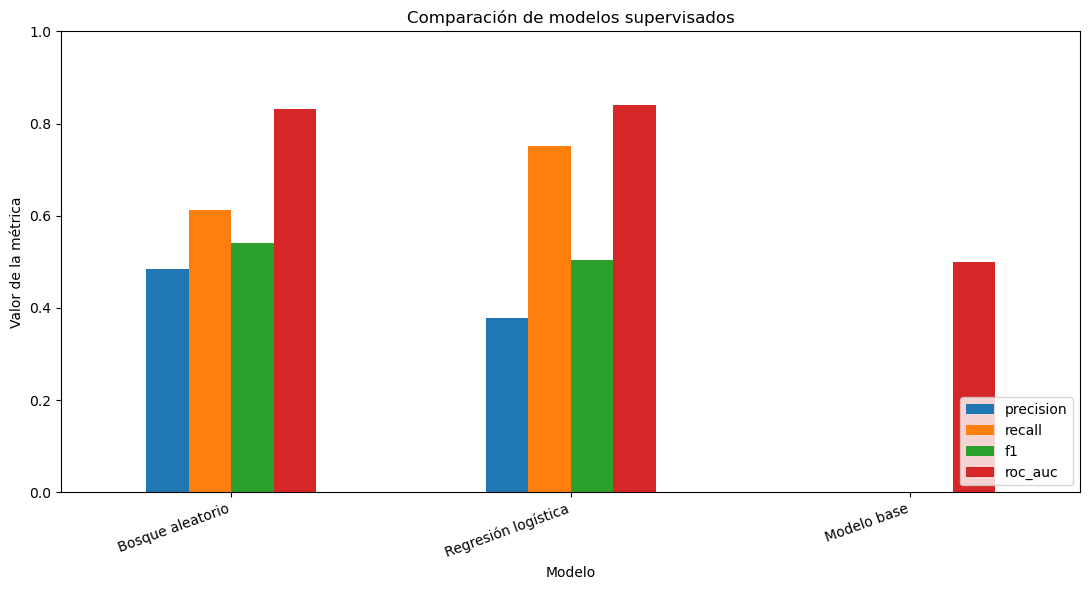

In [17]:
metricas_grafica = resultados_df.set_index(
    "modelo"
)[
    [
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ]
]

plt.figure(figsize=(11, 6))
metricas_grafica.plot(
    kind="bar",
    ax=plt.gca()
)
plt.title("Comparación de modelos supervisados")
plt.xlabel("Modelo")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 13. Selección automática del mejor modelo

El modelo se selecciona por el mayor valor de F1 y utiliza ROC-AUC como criterio secundario.

In [18]:
nombre_mejor_modelo = resultados_df.iloc[0][
    "modelo"
]

mejor_modelo = modelos_entrenados[
    nombre_mejor_modelo
]

prediccion_mejor = predicciones_modelos[
    nombre_mejor_modelo
]

probabilidad_mejor = probabilidades_modelos[
    nombre_mejor_modelo
]

print(
    "Mejor modelo seleccionado:",
    nombre_mejor_modelo
)

print()

print(
    classification_report(
        y_test,
        prediccion_mejor,
        target_names=[
            "No diagnosticado",
            "Diagnosticado"
        ],
        digits=4,
        zero_division=0
    )
)

Mejor modelo seleccionado: Bosque aleatorio

                  precision    recall  f1-score   support

No diagnosticado     0.9169    0.8673    0.8914      2494
   Diagnosticado     0.4836    0.6126    0.5405       506

        accuracy                         0.8243      3000
       macro avg     0.7003    0.7400    0.7160      3000
    weighted avg     0.8438    0.8243    0.8322      3000



## 14. Matriz de confusión

La matriz muestra:

- verdaderos negativos;
- falsos positivos;
- falsos negativos;
- verdaderos positivos.

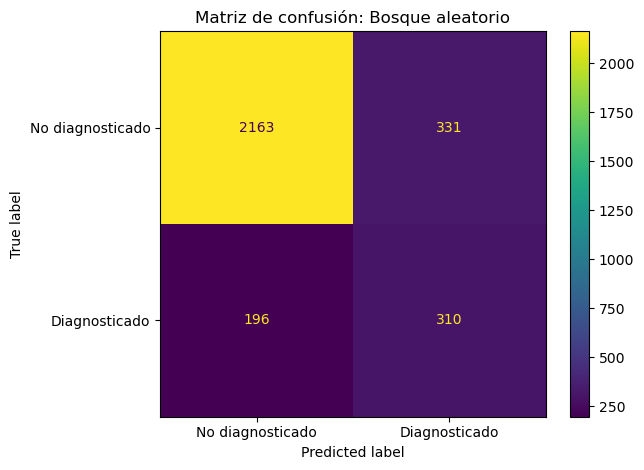

In [19]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    prediccion_mejor,
    display_labels=[
        "No diagnosticado",
        "Diagnosticado"
    ],
    values_format="d"
)

plt.title(
    f"Matriz de confusión: {nombre_mejor_modelo}"
)
plt.tight_layout()
plt.show()

## 15. Curvas ROC

La curva ROC permite comparar la capacidad de discriminación de los modelos para diferentes umbrales.

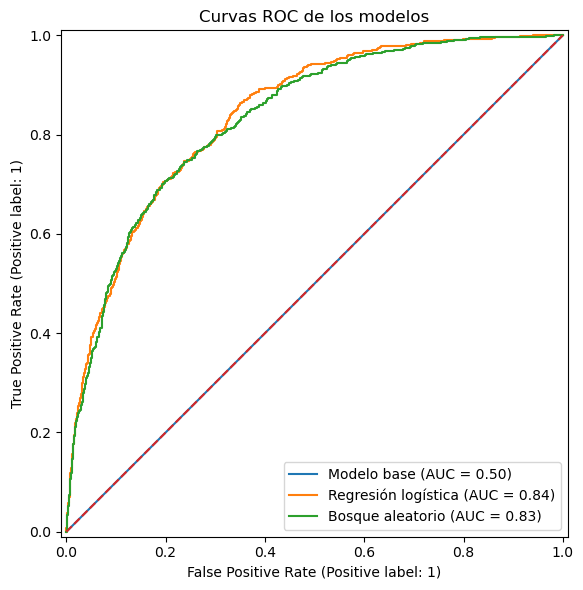

In [20]:
plt.figure(figsize=(8, 6))

for nombre in modelos:
    RocCurveDisplay.from_predictions(
        y_test,
        probabilidades_modelos[nombre],
        name=nombre,
        ax=plt.gca()
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("Curvas ROC de los modelos")
plt.tight_layout()
plt.show()

## 16. Validación cruzada

La validación cruzada repite el entrenamiento en cuatro particiones diferentes. Esto permite comprobar si el rendimiento es estable.

In [21]:
validacion = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=RANDOM_STATE
)

resultados_cv = cross_validate(
    clone(mejor_modelo),
    X,
    y,
    cv=validacion,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    n_jobs=1
)

resumen_cv = pd.DataFrame({
    "metrica": [
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    "promedio": [
        resultados_cv[
            "test_accuracy"
        ].mean(),
        resultados_cv[
            "test_precision"
        ].mean(),
        resultados_cv[
            "test_recall"
        ].mean(),
        resultados_cv[
            "test_f1"
        ].mean(),
        resultados_cv[
            "test_roc_auc"
        ].mean()
    ],
    "desviacion_estandar": [
        resultados_cv[
            "test_accuracy"
        ].std(),
        resultados_cv[
            "test_precision"
        ].std(),
        resultados_cv[
            "test_recall"
        ].std(),
        resultados_cv[
            "test_f1"
        ].std(),
        resultados_cv[
            "test_roc_auc"
        ].std()
    ]
})

display(resumen_cv.round(4))

,metrica,promedio,desviacion_estandar
0,accuracy,0.814,0.003
1,precision,0.461,0.006
2,recall,0.592,0.017
3,f1,0.518,0.010
4,roc_auc,0.821,0.004


## 17. Desarrollo del entrenamiento por cantidad de datos

Para mostrar la evolución del modelo, se entrena con:

- 10 %;
- 25 %;
- 50 %;
- 75 %;
- 100 % del conjunto de entrenamiento.

En cada etapa se registra el rendimiento y el tiempo de entrenamiento.

In [22]:
fracciones = [
    0.10,
    0.25,
    0.50,
    0.75,
    1.00
]

evolucion = []

for fraccion in fracciones:
    if fraccion < 1.0:
        selector = StratifiedShuffleSplit(
            n_splits=1,
            train_size=fraccion,
            random_state=RANDOM_STATE
        )

        indices_subconjunto, _ = next(
            selector.split(
                X_train,
                y_train
            )
        )

        X_subconjunto = X_train.iloc[
            indices_subconjunto
        ]

        y_subconjunto = y_train.iloc[
            indices_subconjunto
        ]
    else:
        X_subconjunto = X_train
        y_subconjunto = y_train

    modelo_etapa = clone(mejor_modelo)

    inicio = perf_counter()

    modelo_etapa.fit(
        X_subconjunto,
        y_subconjunto
    )

    tiempo = perf_counter() - inicio

    prediccion_entrenamiento = (
        modelo_etapa.predict(
            X_subconjunto
        )
    )

    prediccion_prueba = modelo_etapa.predict(
        X_test
    )

    probabilidad_prueba = (
        modelo_etapa.predict_proba(
            X_test
        )[:, 1]
    )

    evolucion.append({
        "porcentaje_entrenamiento": int(
            fraccion * 100
        ),
        "registros_entrenamiento": len(
            X_subconjunto
        ),
        "f1_entrenamiento": f1_score(
            y_subconjunto,
            prediccion_entrenamiento,
            zero_division=0
        ),
        "f1_prueba": f1_score(
            y_test,
            prediccion_prueba,
            zero_division=0
        ),
        "roc_auc_prueba": roc_auc_score(
            y_test,
            probabilidad_prueba
        ),
        "tiempo_seg": tiempo
    })

evolucion_df = pd.DataFrame(evolucion)

display(evolucion_df.round(4))

,porcentaje_entrenamiento,registros_entrenamiento,f1_entrenamiento,f1_prueba,roc_auc_prueba,tiempo_seg
0,10,1200,0.836,0.482,0.813,0.854
1,25,3000,0.792,0.504,0.824,1.313
2,50,6000,0.774,0.524,0.832,2.208
3,75,9000,0.744,0.526,0.832,3.116
4,100,12000,0.724,0.540,0.833,4.155


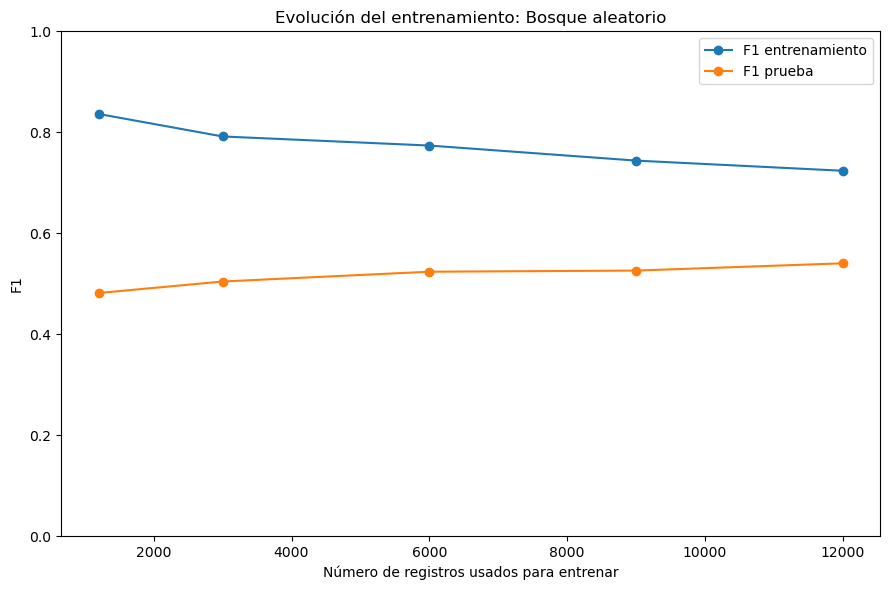

In [23]:
plt.figure(figsize=(9, 6))

plt.plot(
    evolucion_df[
        "registros_entrenamiento"
    ],
    evolucion_df[
        "f1_entrenamiento"
    ],
    marker="o",
    label="F1 entrenamiento"
)

plt.plot(
    evolucion_df[
        "registros_entrenamiento"
    ],
    evolucion_df[
        "f1_prueba"
    ],
    marker="o",
    label="F1 prueba"
)

plt.title(
    "Evolución del entrenamiento: "
    + nombre_mejor_modelo
)

plt.xlabel(
    "Número de registros usados para entrenar"
)

plt.ylabel("F1")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

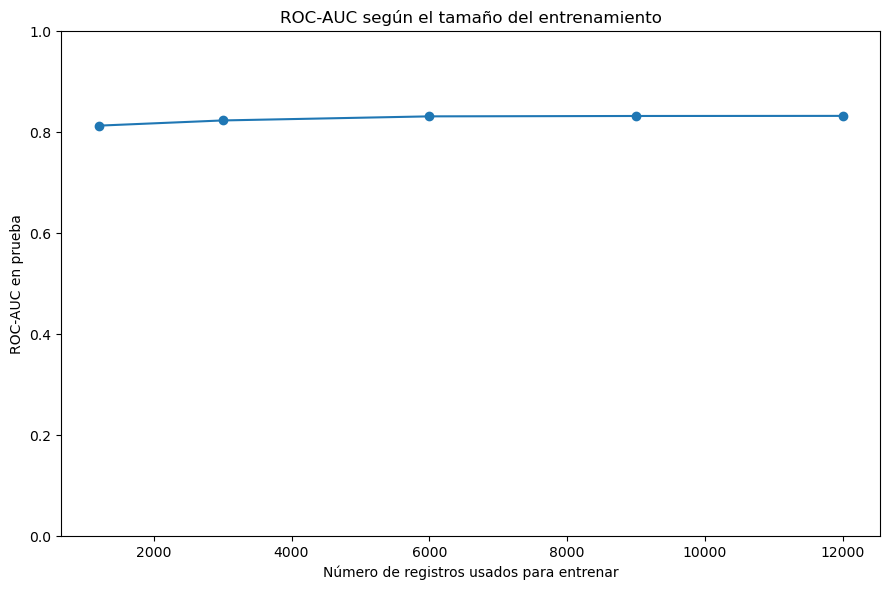

In [24]:
plt.figure(figsize=(9, 6))

plt.plot(
    evolucion_df[
        "registros_entrenamiento"
    ],
    evolucion_df[
        "roc_auc_prueba"
    ],
    marker="o"
)

plt.title(
    "ROC-AUC según el tamaño del entrenamiento"
)

plt.xlabel(
    "Número de registros usados para entrenar"
)

plt.ylabel("ROC-AUC en prueba")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 18. Importancia de las variables

La importancia permite identificar qué características influyen más en las predicciones.

In [25]:
nombres_transformados = (
    mejor_modelo
    .named_steps["preprocesador"]
    .get_feature_names_out()
)

estimador = mejor_modelo.named_steps[
    "modelo"
]

if hasattr(
    estimador,
    "feature_importances_"
):
    valores_importancia = (
        estimador.feature_importances_
    )

    titulo_importancia = (
        "Importancia de variables "
        "del bosque aleatorio"
    )

elif hasattr(
    estimador,
    "coef_"
):
    valores_importancia = np.abs(
        estimador.coef_[0]
    )

    titulo_importancia = (
        "Magnitud de coeficientes "
        "de la regresión logística"
    )

else:
    valores_importancia = np.zeros(
        len(nombres_transformados)
    )

    titulo_importancia = (
        "Importancia de variables"
    )

importancia_df = (
    pd.DataFrame({
        "variable": nombres_transformados,
        "importancia": valores_importancia
    })
    .sort_values(
        "importancia",
        ascending=False
    )
    .reset_index(drop=True)
)

display(importancia_df.head(15))

,variable,importancia
0,numericas__imc,0.422
1,numericas__edad,0.180
2,numericas__presion_sistolica,0.115
3,numericas__colesterol_ldl,0.113
4,numericas__presion_diastolica,0.078
5,categoricas__tipo_area_Rural,0.010
6,categoricas__tipo_area_Urbana,0.009
7,categoricas__tipo_area_Periurbana,0.009
8,categoricas__region_Angelópolis,0.009
9,categoricas__sexo_F,0.009


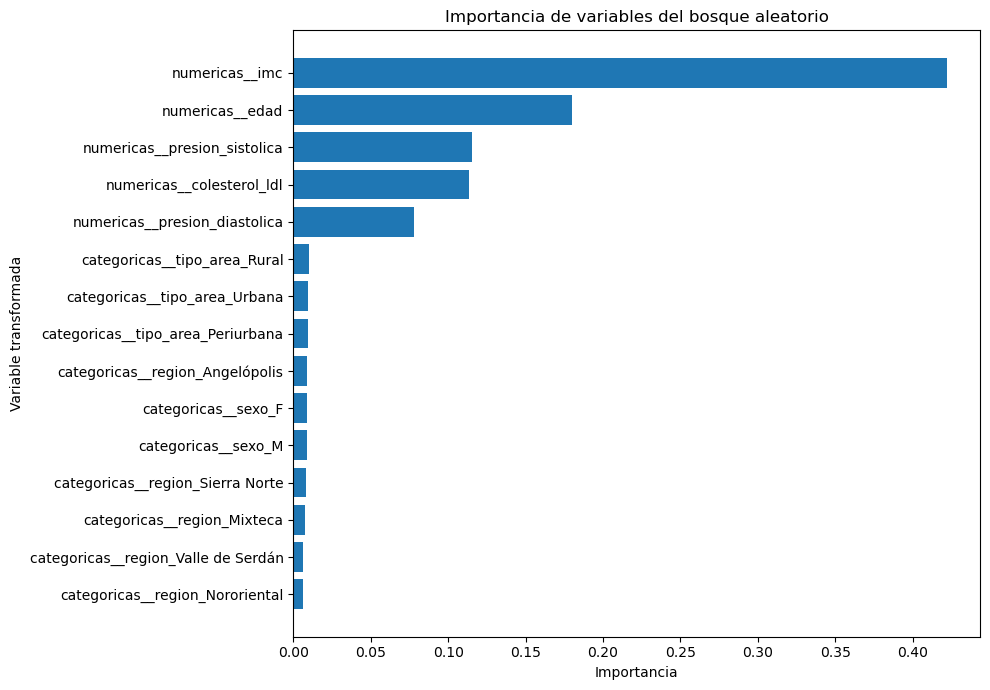

In [26]:
top_importancia = (
    importancia_df
    .head(15)
    .sort_values("importancia")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_importancia["variable"],
    top_importancia["importancia"]
)

plt.title(titulo_importancia)
plt.xlabel("Importancia")
plt.ylabel("Variable transformada")
plt.tight_layout()
plt.show()

## 19. Predicción para los 15,000 pacientes

El mejor modelo se aplica a todos los registros para obtener:

- probabilidad estimada;
- predicción binaria;
- nivel de riesgo visual.

In [27]:
pacientes_df["probabilidad_modelo"] = (
    mejor_modelo.predict_proba(X)[:, 1]
)

pacientes_df["prediccion_modelo"] = (
    mejor_modelo.predict(X)
)

pacientes_df["nivel_riesgo_modelo"] = pd.cut(
    pacientes_df["probabilidad_modelo"],
    bins=[
        -0.01,
        0.25,
        0.50,
        0.75,
        1.00
    ],
    labels=[
        "Bajo",
        "Moderado",
        "Alto",
        "Muy alto"
    ]
)

columnas_resultado = [
    "paciente_id",
    "municipio",
    "region",
    "edad",
    "imc",
    "presion_sistolica",
    "colesterol_ldl",
    "diagnostico_texto",
    "probabilidad_modelo",
    "prediccion_modelo",
    "nivel_riesgo_modelo"
]

display(
    pacientes_df[columnas_resultado]
    .sort_values(
        "probabilidad_modelo",
        ascending=False
    )
    .head(20)
)

,paciente_id,municipio,region,edad,imc,presion_sistolica,colesterol_ldl,diagnostico_texto,probabilidad_modelo,prediccion_modelo,nivel_riesgo_modelo
13189,PUE987-03190,Zacatlán,Mixteca,82,49.100,159,232,Diagnosticado,0.957,1,Muy alto
12712,PUE987-02713,Zacatlán,Mixteca,84,50.500,169,227,Diagnosticado,0.954,1,Muy alto
2287,PUE-CV-02288,Puebla,Angelópolis,88,45.100,166,206,Diagnosticado,0.948,1,Muy alto
12641,PUE987-02642,Cuetzalan,Sierra Norte,84,43.400,162,224,Diagnosticado,0.947,1,Muy alto
14938,PUE987-04939,Teziutlán,Mixteca,83,50.700,182,192,Diagnosticado,0.945,1,Muy alto
11204,PUE987-01205,Teziutlán,Sierra Norte,87,43.600,158,220,Diagnosticado,0.945,1,Muy alto
11836,PUE987-01837,Teziutlán,Mixteca,71,47.700,174,220,Diagnosticado,0.943,1,Muy alto
5171,PUE123-00172,Libres,Angelópolis,81,44.800,183,249,Diagnosticado,0.941,1,Muy alto
14410,PUE987-04411,Chignahuapan,Mixteca,81,44.500,162,206,Diagnosticado,0.940,1,Muy alto
10453,PUE987-00454,Teziutlán,Sierra Norte,89,47.400,154,216,Diagnosticado,0.939,1,Muy alto


## 20. Resumen por municipio

Para cada municipio se calculan:

- total de pacientes;
- pacientes diagnosticados;
- porcentaje diagnosticado;
- predicciones positivas;
- probabilidad promedio estimada.

In [28]:
resumen_municipios = (
    pacientes_df
    .groupby("municipio")
    .agg(
        total_pacientes=(
            "paciente_id",
            "count"
        ),
        diagnosticados=(
            "diagnostico_diabetes",
            "sum"
        ),
        predicciones_positivas=(
            "prediccion_modelo",
            "sum"
        ),
        probabilidad_promedio=(
            "probabilidad_modelo",
            "mean"
        ),
        latitud=(
            "latitud",
            "mean"
        ),
        longitud=(
            "longitud",
            "mean"
        )
    )
    .reset_index()
)

resumen_municipios[
    "porcentaje_diagnosticados"
] = (
    resumen_municipios[
        "diagnosticados"
    ]
    / resumen_municipios[
        "total_pacientes"
    ]
    * 100
)

resumen_municipios = (
    resumen_municipios
    .sort_values(
        [
            "porcentaje_diagnosticados",
            "diagnosticados"
        ],
        ascending=False
    )
)

display(
    resumen_municipios
    .head(20)
    .round(3)
)

,municipio,total_pacientes,diagnosticados,predicciones_positivas,probabilidad_promedio,latitud,longitud,porcentaje_diagnosticados
7,Izúcar de Matamoros,1002,192,237,0.316,19.399,-98.010,19.162
5,Cuetzalan,999,188,241,0.315,19.401,-97.999,18.819
8,Libres,1016,181,266,0.330,19.436,-97.972,17.815
9,Pahuatlán,1022,182,244,0.311,19.401,-98.017,17.808
6,Huauchinango,471,83,119,0.315,19.145,-97.942,17.622
13,Tecamachalco,965,169,212,0.309,19.397,-98.054,17.513
4,Chignahuapan,996,171,231,0.312,19.387,-98.022,17.169
0,Acajete,1017,174,240,0.320,19.406,-98.010,17.109
19,Zacatlán,995,170,219,0.308,19.420,-98.010,17.085
16,Tlahuapan,492,83,105,0.287,19.119,-97.948,16.870


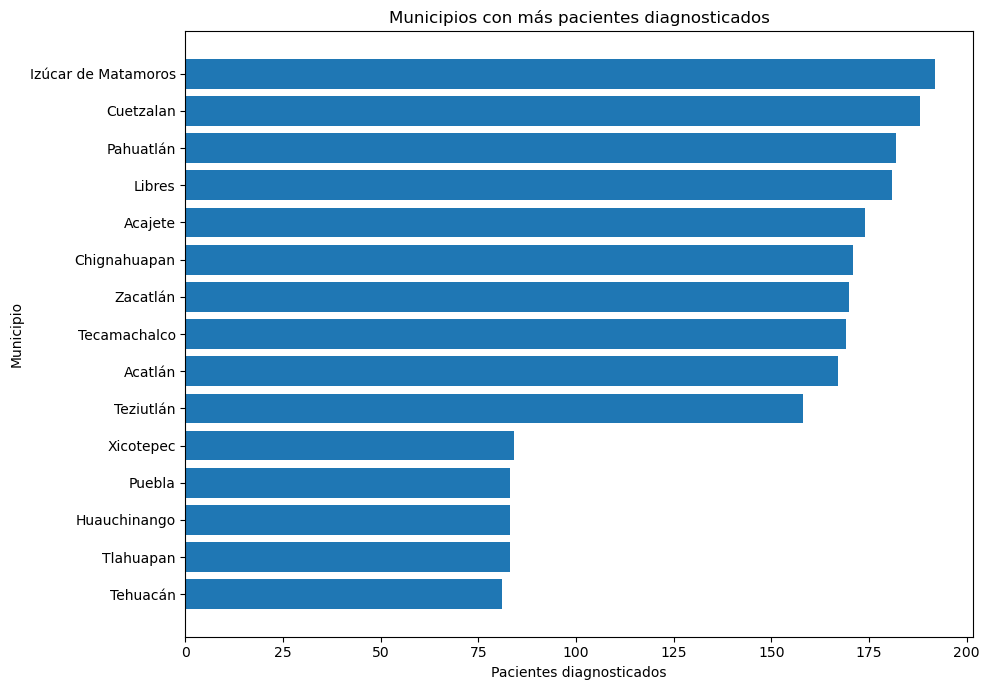

In [29]:
top_municipios = (
    resumen_municipios
    .sort_values(
        "diagnosticados",
        ascending=False
    )
    .head(15)
    .sort_values("diagnosticados")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_municipios["municipio"],
    top_municipios["diagnosticados"]
)

plt.title(
    "Municipios con más pacientes diagnosticados"
)

plt.xlabel("Pacientes diagnosticados")
plt.ylabel("Municipio")
plt.tight_layout()
plt.show()

## 21. Mapa de calor de pacientes diagnosticados

El mapa utiliza las coordenadas de todos los pacientes cuyo diagnóstico sintético es positivo.

In [30]:
centro_puebla = [
    pacientes_df["latitud"].mean(),
    pacientes_df["longitud"].mean()
]

diagnosticados_df = pacientes_df[
    pacientes_df["diagnostico_diabetes"] == 1
].copy()

mapa_diagnosticados = folium.Map(
    location=centro_puebla,
    zoom_start=8,
    tiles="CartoDB positron"
)

datos_calor_diagnosticados = (
    diagnosticados_df[
        ["latitud", "longitud"]
    ]
    .dropna()
    .values
    .tolist()
)

plugins.HeatMap(
    datos_calor_diagnosticados,
    radius=18,
    blur=14,
    min_opacity=0.30
).add_to(mapa_diagnosticados)

print(
    "Pacientes diagnosticados representados:",
    f"{len(diagnosticados_df):,}"
)

mapa_diagnosticados

Pacientes diagnosticados representados: 2,532


## 22. Mapa interactivo de probabilidad estimada

El siguiente mapa combina:

- mapa de calor con la probabilidad estimada de los 15,000 pacientes;
- círculos por municipio;
- tamaño del círculo de acuerdo con la cantidad de diagnósticos;
- ventanas emergentes con el resumen municipal.

In [31]:
mapa_probabilidad = folium.Map(
    location=centro_puebla,
    zoom_start=8,
    tiles="CartoDB dark_matter"
)

datos_calor_probabilidad = (
    pacientes_df[
        [
            "latitud",
            "longitud",
            "probabilidad_modelo"
        ]
    ]
    .dropna()
    .values
    .tolist()
)

plugins.HeatMap(
    datos_calor_probabilidad,
    radius=17,
    blur=15,
    min_opacity=0.25,
    max_zoom=10
).add_to(mapa_probabilidad)

for _, fila in resumen_municipios.iterrows():
    radio = max(
        4,
        np.sqrt(
            fila["diagnosticados"]
        ) * 1.4
    )

    folium.CircleMarker(
        location=[
            fila["latitud"],
            fila["longitud"]
        ],
        radius=radio,
        tooltip=fila["municipio"],
        popup=(
            f"<b>Municipio:</b> "
            f"{fila['municipio']}<br>"
            f"<b>Total de pacientes:</b> "
            f"{int(fila['total_pacientes'])}<br>"
            f"<b>Diagnosticados:</b> "
            f"{int(fila['diagnosticados'])}<br>"
            f"<b>Porcentaje:</b> "
            f"{fila['porcentaje_diagnosticados']:.2f}%<br>"
            f"<b>Probabilidad promedio:</b> "
            f"{fila['probabilidad_promedio']:.3f}"
        ),
        fill=True,
        fill_opacity=0.70
    ).add_to(mapa_probabilidad)

mapa_probabilidad

## 23. Ejemplo de predicción individual

La función recibe los datos de una persona y devuelve la probabilidad estimada y la clase predicha.

In [32]:
def predecir_paciente(
    edad,
    imc,
    presion_sistolica,
    presion_diastolica,
    colesterol_ldl,
    sexo,
    region,
    tipo_area
):
    nuevo_paciente = pd.DataFrame([{
        "edad": edad,
        "imc": imc,
        "presion_sistolica": presion_sistolica,
        "presion_diastolica": presion_diastolica,
        "colesterol_ldl": colesterol_ldl,
        "sexo": sexo,
        "region": region,
        "tipo_area": tipo_area
    }])

    probabilidad = (
        mejor_modelo
        .predict_proba(
            nuevo_paciente
        )[0, 1]
    )

    prediccion = (
        mejor_modelo
        .predict(
            nuevo_paciente
        )[0]
    )

    resultado = pd.DataFrame([{
        "probabilidad_estimada": probabilidad,
        "prediccion": (
            "Diagnosticado"
            if prediccion == 1
            else "No diagnosticado"
        )
    }])

    return resultado


ejemplo = predecir_paciente(
    edad=58,
    imc=32.4,
    presion_sistolica=148,
    presion_diastolica=94,
    colesterol_ldl=172,
    sexo="F",
    region=pacientes_df["region"].mode()[0],
    tipo_area="Urbana"
)

display(ejemplo)

,probabilidad_estimada,prediccion
0,0.523,Diagnosticado


## 24. Exportación opcional

El notebook no crea archivos automáticamente. Para guardar los resultados, se pueden descomentar las siguientes instrucciones.

In [33]:
# pacientes_df.to_csv(
#     "pacientes_puebla_15000_con_predicciones.csv",
#     index=False,
#     encoding="utf-8-sig"
# )

# resumen_municipios.to_csv(
#     "resumen_diabetes_por_municipio.csv",
#     index=False,
#     encoding="utf-8-sig"
# )

# print("Archivos exportados correctamente.")

# Conclusiones

El notebook muestra el desarrollo completo de un análisis supervisado:

1. Se cargaron los 15,000 registros.
2. Se verificó la calidad de los datos.
3. Se construyó una etiqueta sintética reproducible.
4. Se separaron los datos en entrenamiento y prueba.
5. Se aplicó preprocesamiento mediante una tubería.
6. Se entrenaron tres modelos.
7. Se compararon métricas y tiempos de entrenamiento.
8. Se seleccionó el mejor modelo.
9. Se generó una matriz de confusión.
10. Se construyeron curvas ROC.
11. Se aplicó validación cruzada.
12. Se mostró la evolución del modelo conforme aumentó el número de datos.
13. Se analizaron las variables más importantes.
14. Se calcularon predicciones para los 15,000 pacientes.
15. Se visualizaron los resultados mediante gráficas y mapas de calor.

## Limitaciones

- La variable de diagnóstico es sintética.
- No se cuenta con glucosa en ayunas ni HbA1c.
- Los resultados no deben utilizarse para tomar decisiones médicas.
- Un proyecto real debe trabajar con diagnósticos clínicos confirmados, consentimiento, anonimización y controles de seguridad.